In [4]:
import scanpy as sc
import pandas as pd
import anndata as ad
import harmonypy as hmå
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

from pilotpy.tools import *  #scvi env
from pilotpy.plot import *
import scanpy as sc

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import pandas as pd
import harmonypy as hm
import os
desired_path = '/beegfs/data/CostaLab/spatial_kidney_kuppelab/Human_mouse_all_xenium' # Or the folder your current notebook is in
os.chdir(desired_path)

### All his include humna.mouse for adenin

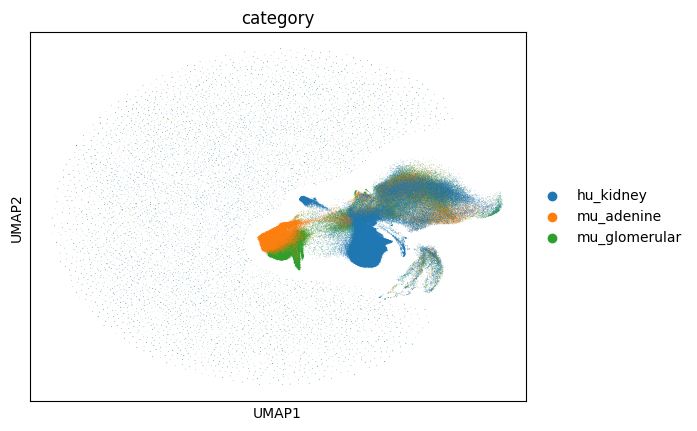

In [ ]:
#adata=sc.read_h5ad('/beegfs/data/CostaLab/spatial_kidney_kuppelab/Human_mouse_all_xenium/all_his.h5ad')


#adata.obs['Slide_ID_clean'] = adata.obs['Slide_ID'].astype(str).str.replace('f$', '', regex=True)

#mapping = pd.read_csv('/beegfs/data/CostaLab/spatial_kidney_kuppelab/Human_mouse_all_xenium/mapping.csv', sep=';')
#mapping['Slide_ID'] = mapping['xenium_slide'].astype(str) + '-' + mapping['xenium_region'].astype(str)

#mapping_unique = mapping.drop_duplicates(subset='Slide_ID', keep='first')
#sample_dict = dict(zip(mapping_unique['Slide_ID'], mapping_unique['sample_ID']))
#category_dict = dict(zip(mapping_unique['Slide_ID'], mapping_unique['category']))

#adata.obs['sample_ID'] = adata.obs['Slide_ID_clean'].astype(str).map(sample_dict)
#adata.obs['category'] = adata.obs['Slide_ID_clean'].astype(str).map(category_dict)

#ho = hm.run_harmony(adata.obsm["X_pca"], adata_human_mouse.obs, ["category"])
#adata.obsm["X_pca_harmony"] = ho.Z_corr
#sc.pp.neighbors(adata, n_neighbors=15, use_rep="X_pca_harmony")
#sc.tl.leiden(adata, resolution=0.00001)
#sc.pl.umap(adata,color='category')

In [ ]:
#adata=sc.read_h5ad('/beegfs/data/CostaLab/spatial_kidney_kuppelab/Human_mouse_all_xenium/all_his.h5ad')

## Human Transcriptomics

In [5]:
spatial_data=sc.read_h5ad('hu_kidney.h5ad')

In [56]:

spatial_data.obs['eGFR_clean'] = (
    spatial_data.obs['eGFR_(CKD-EPI)']
    .astype(str)
    .str.replace('>', '', regex=False)
    .str.strip()
)

# turn "nan" strings back into real NaN if needed
spatial_data.obs['eGFR_clean'] = spatial_data.obs['eGFR_clean'].replace('nan', np.nan)
spatial_data = spatial_data[~spatial_data.obs['eGFR_clean'].isin([np.nan])]

spatial_data.obs['eGFR_clean'] = pd.to_numeric(spatial_data.obs['eGFR_clean'], errors='coerce')

spatial_data.obs['eGFR_group'] = pd.cut(
    spatial_data.obs['eGFR_clean'],
    bins=[-np.inf, 60, 90, np.inf],
    labels=['≤60', '60-90', '≥90'],
    right=False
)



In [ ]:
spatial_data.obs['sample_ID_']=spatial_data.obs['sample_ID_1'].astype(str)+'_'+spatial_data.obs['eGFR_group'].astype(str)

### first run the histology trajectory and then run this line

In [59]:

spatial_data=spatial_data[spatial_data.obs['sample_ID_'].isin(list(adata_human.obs['sample_ID_']))].copy()

In [ ]:
spatial_data

In [60]:
spatial_data

AnnData object with n_obs × n_vars = 441500 × 5001
    obs: 'cell_id', 'transcript_counts', 'control_probe_counts', 'genomic_control_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'nucleus_count', 'segmentation_method', 'region', 'z_level', 'cell_labels', 'Cell ID', 'Donor', 'Sample', 'year', 'tissue_type', 'origin', 'category', 'age', 'sex', 'sample_group', 'carcinoma', 'IFTA', 'eGFR_(CKD-EPI)', 'CKD_stage', 'kreatinine_(50-100 umol_L)', 'history', 'tacco', 'tacco_2nd', 'singler', 'singler_class', 'phispace', 'phispace_2nd', 'insitutype', 'consensus', 'agreement_score', 'is_ambiguous', 'n_counts', 'n_genes', 'leiden_1', 'leiden_0.5', 'leiden_3', 'annotation_highres', 'sample_ID_1', 'sample_ID_2', 'eGFR_clean', 'eGFR_group', 'sample_ID_'
    var: 'gene_ids', 'feature_types', 'genome'
    uns: 'annotation_highres_colors', 'consensus_colors', 'leiden_0.5', 'leiden_1', 'leiden_3', 'log1p', 'neigh

In [8]:
wasserstein_distance(spatial_data,emb_matrix='X_pca_harmony',
clusters_col='annotation_highres',sample_col='sample_ID_',status='eGFR_group',metric='euclidean')

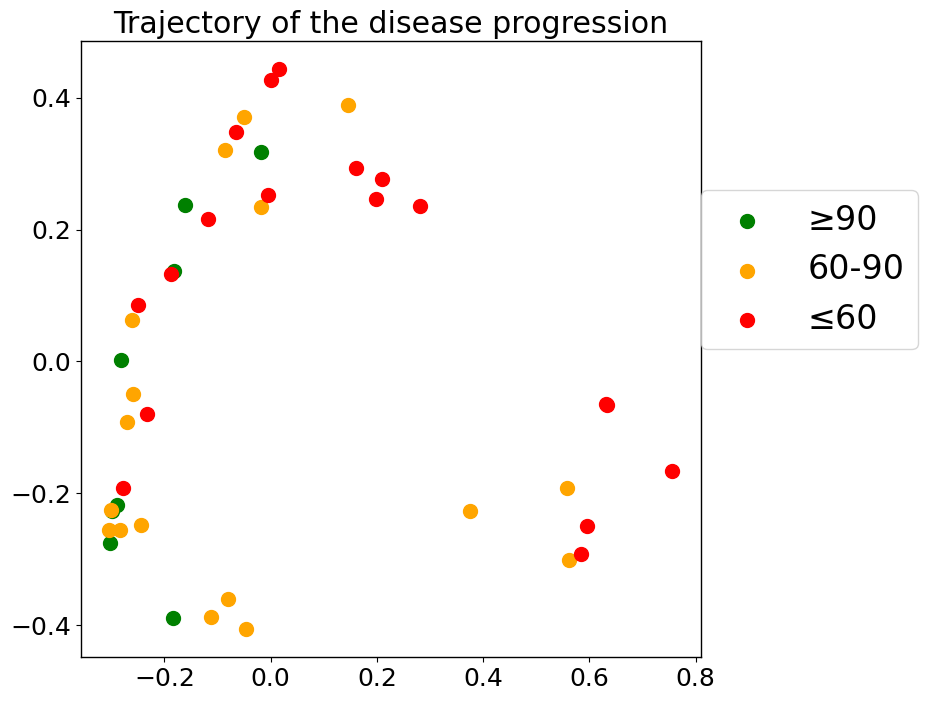

In [14]:
trajectory(spatial_data,colors=['green','orange','red'],label_act=False,font_size=18,knn=15,figsize=(8,8),legend_order=['≥90','60-90','≤60'], location_labels=(1,0.5))

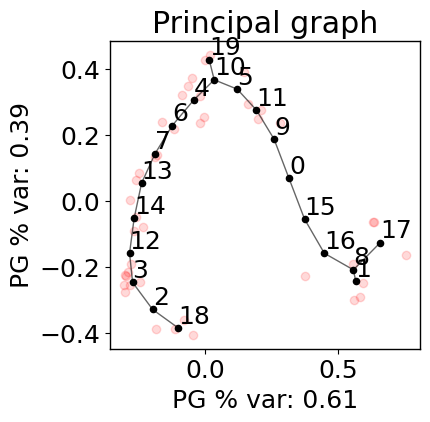

In [15]:
fit_pricipla_graph(spatial_data, source_node =18,figsize=(4,4))

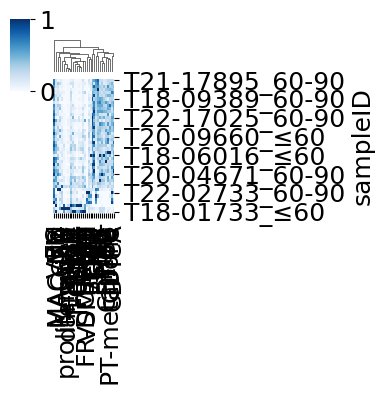

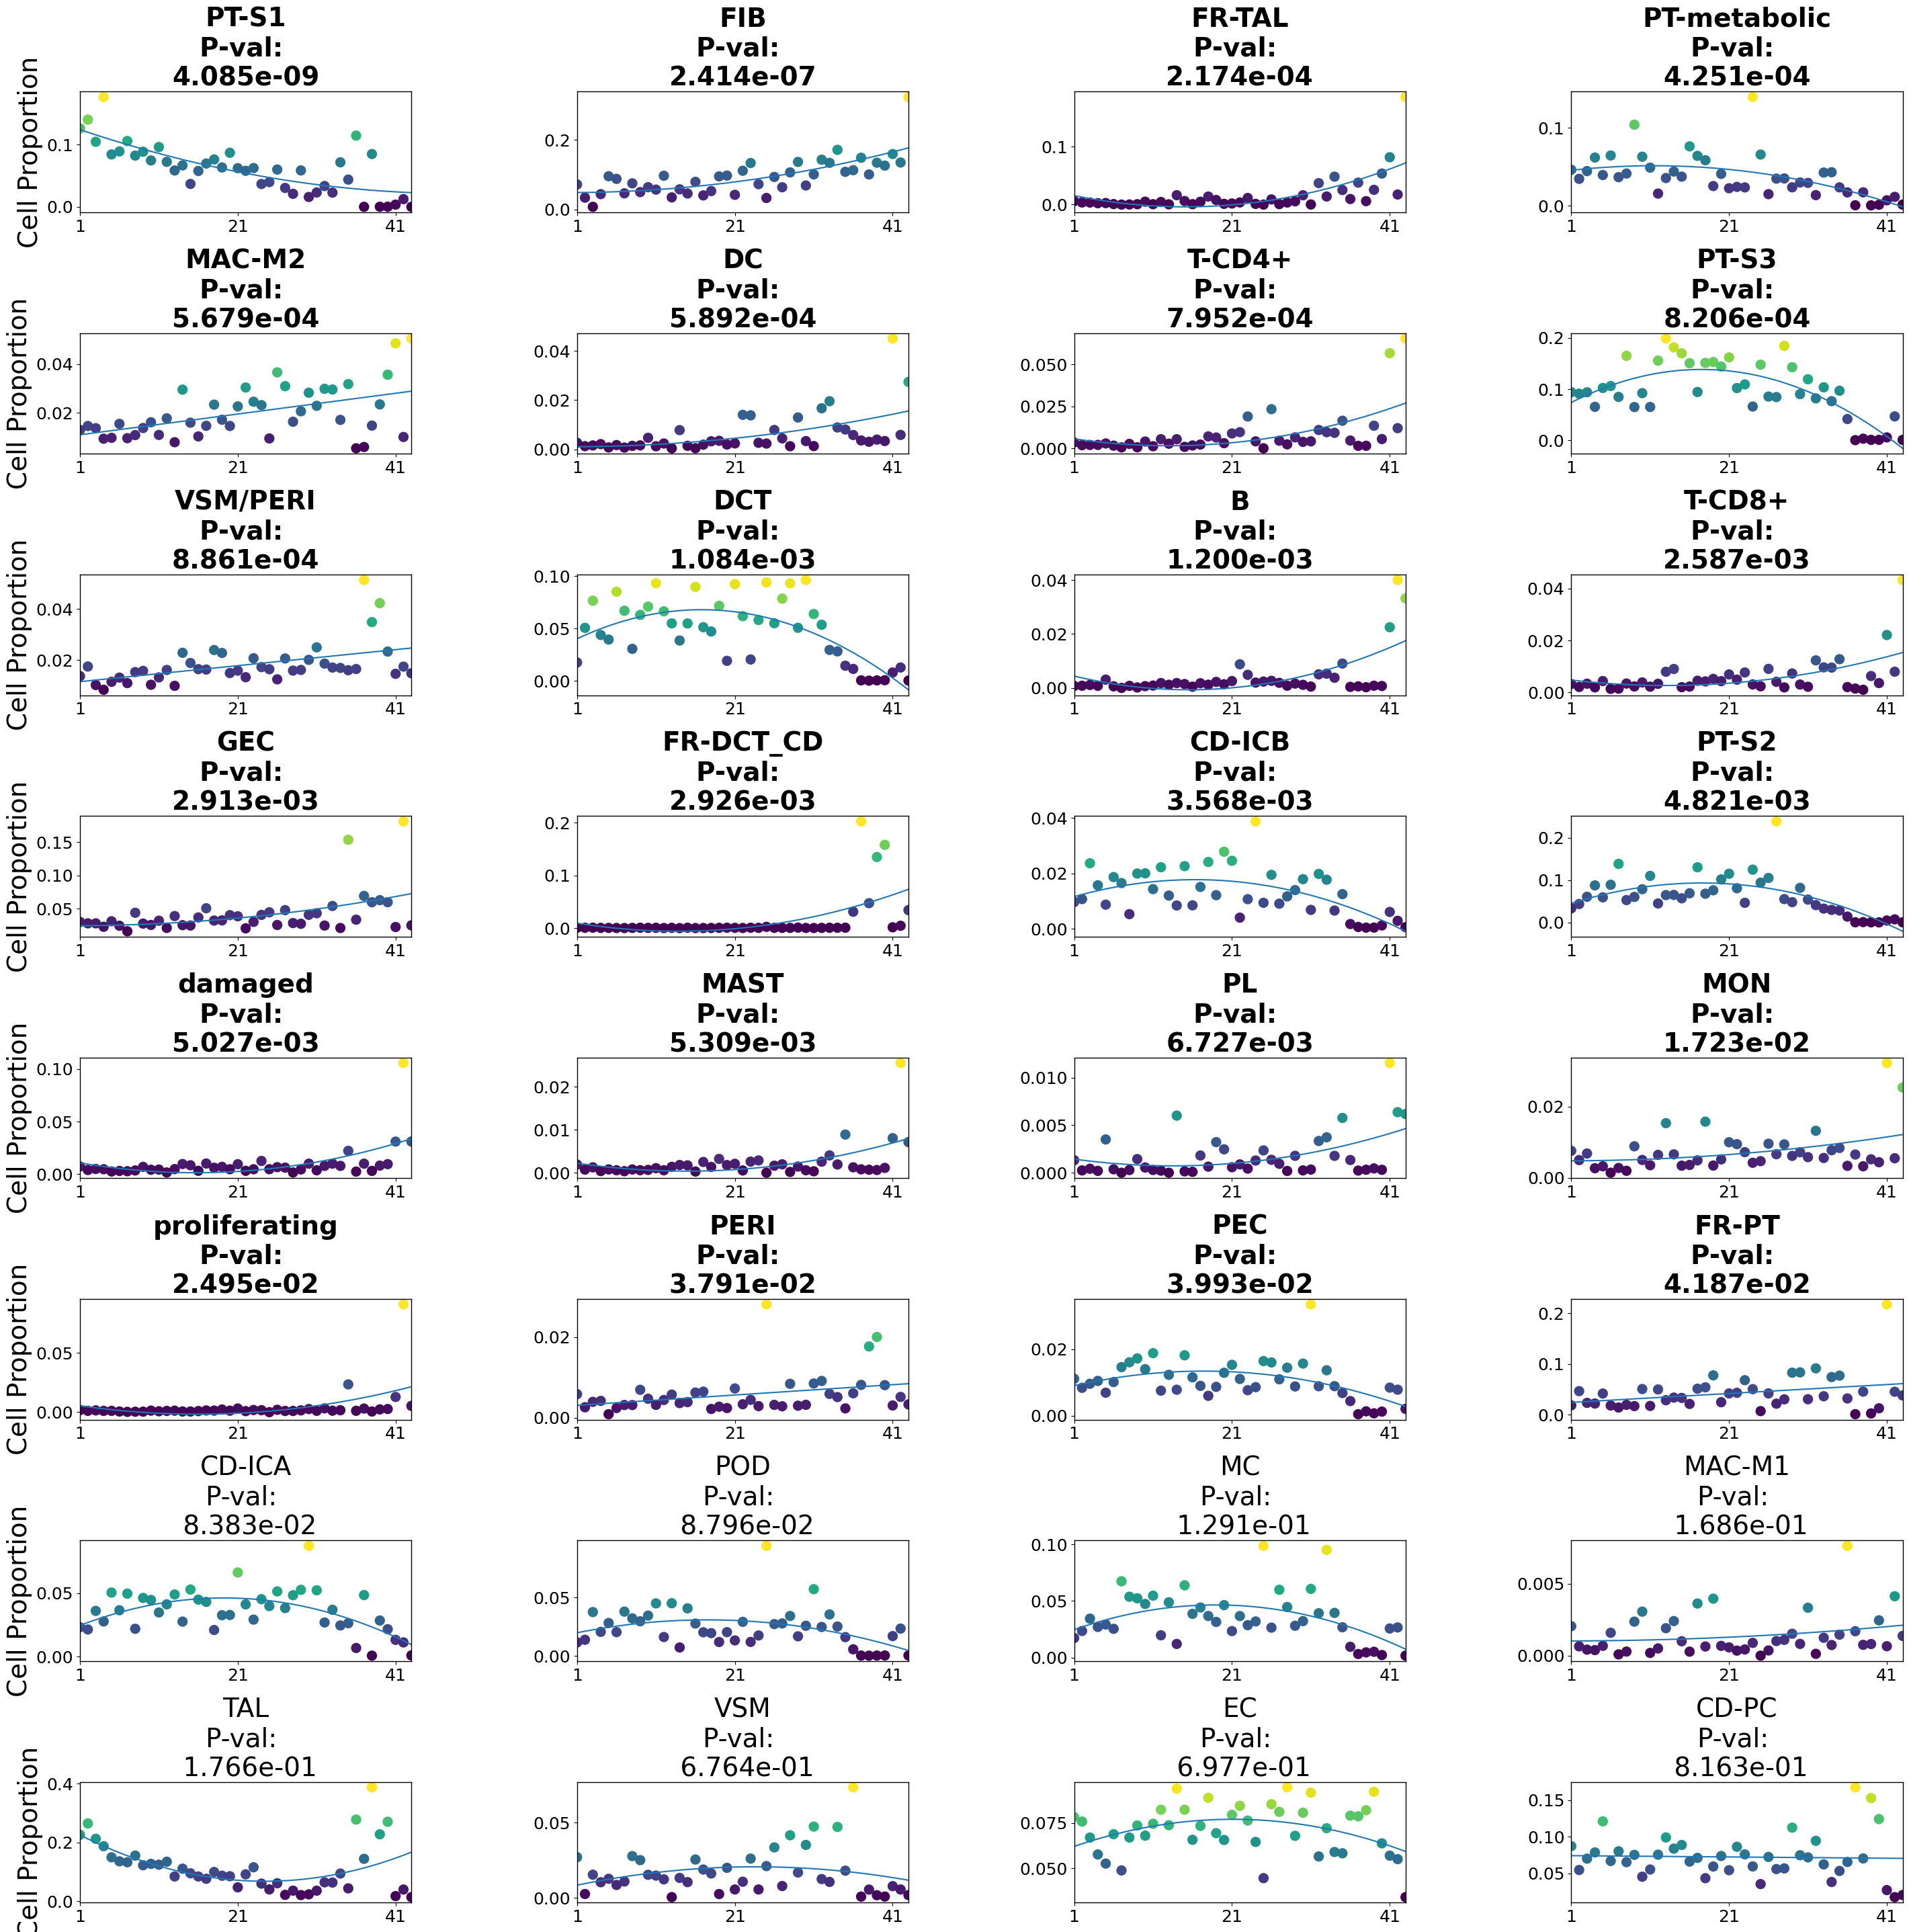

In [16]:
cell_importance(spatial_data,height=35,width=35,fontsize=28,xlim=20,figsize=(4,4))

Saved 43 core plots to cores_annotation_highres_human/


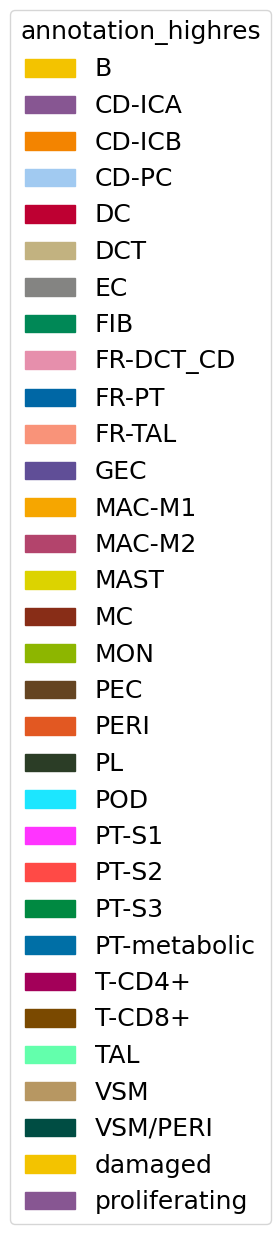

In [22]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# **Plot each core's cells at their true spatial coordinates, colored by annotation_highres**
cluster_col = "annotation_highres"
core_col = "sample_ID_1"  # adjust if spatial_data uses a different column to identify cores
group_col = "eGFR_group"  # experimental group column
point_size = 10          # cell-level points are much smaller than the 224px patches

output_dir_cells = "cores_annotation_highres_human"
os.makedirs(output_dir_cells, exist_ok=True)

coords = spatial_data.obsm["spatial"]
spatial_data.obs[cluster_col] = spatial_data.obs[cluster_col].astype("category")
categories = spatial_data.obs[cluster_col].cat.categories

# **Maximum-contrast palette (Kelly's 20 colors + extensions) — stays distinguishable up to ~30 categories**
distinct_palette = [
    "#F3C300", "#875692", "#F38400", "#A1CAF1", "#BE0032", "#C2B280", "#848482",
    "#008856", "#E68FAC", "#0067A5", "#F99379", "#604E97", "#F6A600", "#B3446C",
    "#DCD300", "#882D17", "#8DB600", "#654522", "#E25822", "#2B3D26",
    "#1CE6FF", "#FF34FF", "#FF4A46", "#008941", "#006FA6", "#A30059",
    "#7A4900", "#63FFAC", "#B79762", "#004D43",
]
if len(categories) > len(distinct_palette):
    print(f"Warning: {len(categories)} categories but only {len(distinct_palette)} distinct colors defined — some will repeat.")
color_map = dict(zip(categories, (distinct_palette * 2)[:len(categories)]))

for slide_id in spatial_data.obs[core_col].unique():
    mask = (spatial_data.obs[core_col] == slide_id).values
    sub_coords = coords[mask]
    sub_labels = spatial_data.obs.loc[mask, cluster_col]
    group = spatial_data.obs.loc[mask, group_col].iloc[0]  # assumes one group per core

    fig, ax = plt.subplots(figsize=(10, 10))
    for cat in categories:
        cat_mask = (sub_labels == cat).values
        if cat_mask.sum() == 0:
            continue
        ax.scatter(sub_coords[cat_mask, 0], sub_coords[cat_mask, 1],
                   s=point_size, color=color_map[cat], label=cat, linewidths=0)

    ax.invert_yaxis()
    ax.set_aspect("equal")
    ax.axis("off")

    fig.tight_layout()
    fig.savefig(os.path.join(output_dir_cells, f"{slide_id}_{group}.png"), dpi=200, bbox_inches="tight")
    plt.close(fig)

print(f"Saved {spatial_data.obs[core_col].nunique()} core plots to {output_dir_cells}/")

# **Save the annotation_highres legend separately**
fig, ax = plt.subplots(figsize=(3, len(categories) * 0.3))
legend_handles = [mpatches.Patch(color=color_map[c], label=c) for c in categories]
ax.legend(handles=legend_handles, title=cluster_col, loc="center")
ax.axis("off")
fig.tight_layout()
fig.savefig(os.path.join(output_dir_cells, f"_legend_{cluster_col}.png"), dpi=200, bbox_inches="tight")
plt.show()

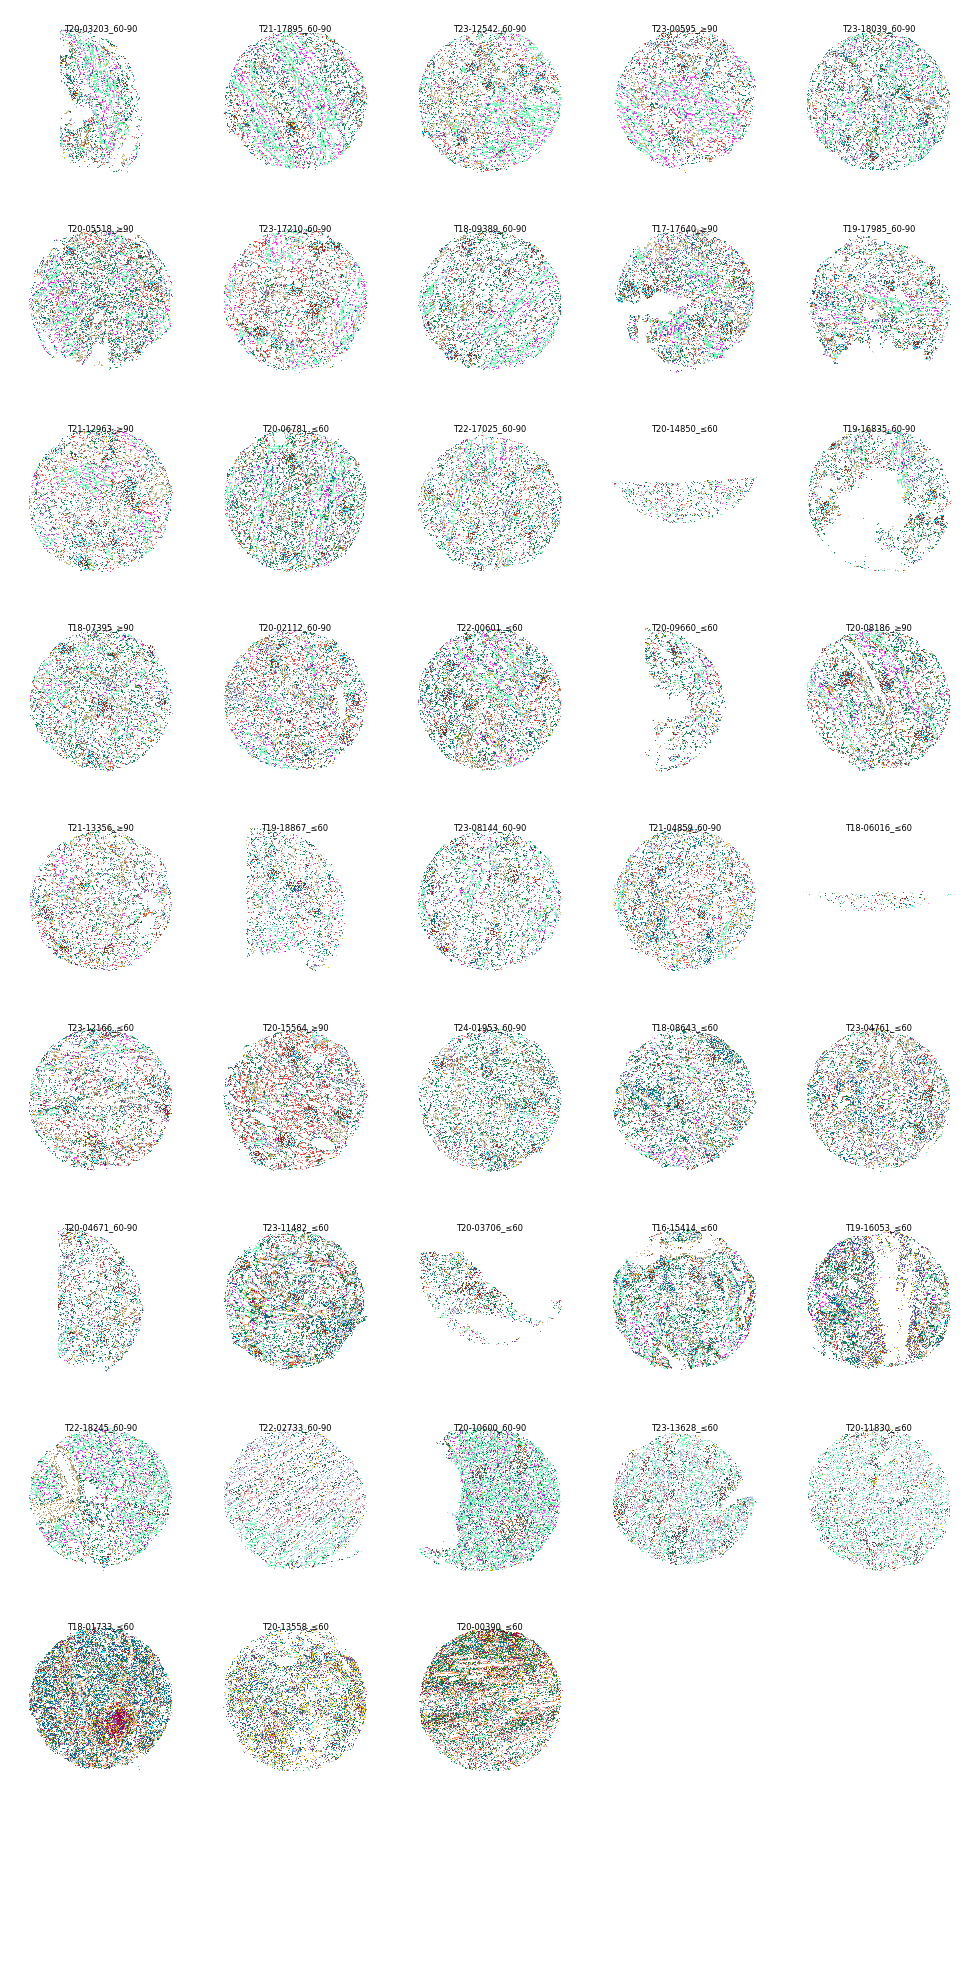

Saved grid to Results_PILOT/Cores_Patche_ordered.pdf


In [23]:
spatial_data.uns['orders'].rename(columns={'Time_score': 'pseudotime'}, inplace=True)
create_sample_grid(df=spatial_data.uns['orders'],image_dir='cores_annotation_highres_human/', output_path="Results_PILOT/Cores_Patche_ordered.pdf",zoom=0.06)

## Human his

In [ ]:
#adata_human=sc.read_h5ad('/beegfs/data/CostaLab/spatial_kidney_kuppelab/Human_mouse_all_xenium/all_his_see_batch.h5ad')
#adata_human=adata_human[adata_human.obs['category'].isin(['hu_kidney'])].copy()
#sc.pp.neighbors(adata_human, n_neighbors=15, use_rep="X_pca_harmony")
#sc.tl.leiden(adata_human, resolution=0.00001)
#adata_human=adata_human[adata_human.obs['leiden'].isin(['0','1'])].copy()
#sc.pp.neighbors(adata_human, n_neighbors=15, use_rep="X_pca_harmony")
#sc.tl.leiden(adata_human, resolution=0.2)
#adata_human=adata_human[~adata_human.obs['leiden'].isin(['1','4','9','10'])].copy()

#Reifen  #Profiltiefe...Reifenprofil...#keine Risse...no crack..keine Dellen...Dents...Keine Beulen..no bumps..
#Reifendruck Luftdruck...Nicht Beshadigt..NOT damage
#Motorhaube...Bonnet.....Motoriol...scheibenwische...OL stand..oil level
#####Qutions
#3 things : 1.profiltiefe..mindestens...1 comma 6 milimiter...2.reifenDruck...3.Refein nicht beschagtig..
#Wie vile ReifenDruck..luftdruck....open the door
##### Light
#1. standlicht/Warmblinkanlage einschlaten.... hazardlicht
#Woher wissen Sie dass .... licht ist an? 

In [9]:

donor_group = spatial_data.obs.drop_duplicates(subset='sample_ID_1')
group_dict = dict(zip(donor_group['sample_ID_1'].astype(str), donor_group['eGFR_group'].astype(str)))


In [52]:
!pwd

/beegfs/data/CostaLab/spatial_kidney_kuppelab/Human_mouse_all_xenium


In [13]:
adata_human=sc.read_h5ad('human_his.h5ad')
adata_human=adata_human[~adata_human.obs['leiden'].isin(['7','6','8'])].copy()
adata_human.obs['sample_ID'] = adata_human.obs['sample_ID'].astype(str).str.split(' ').str[0]

In [14]:
adata_human.obs['group'] = adata_human.obs['sample_ID'].map(group_dict)

In [15]:
adata_human=adata_human[adata_human.obs['sample_ID'].isin(list(donor_group['sample_ID_1']))].copy()

In [ ]:
#sc.tl.leiden(adata_human, resolution=0.4)

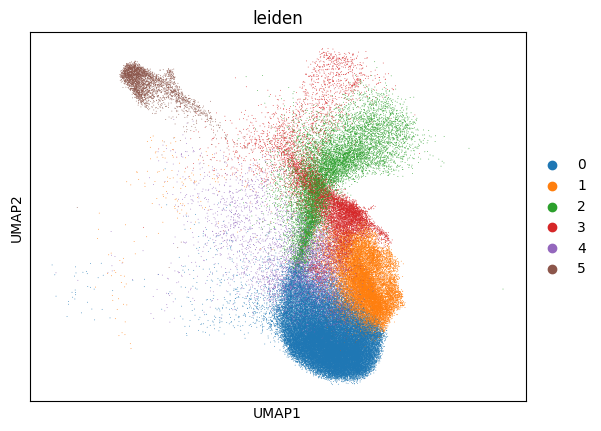

In [16]:
sc.pl.umap(adata_human,color='leiden')

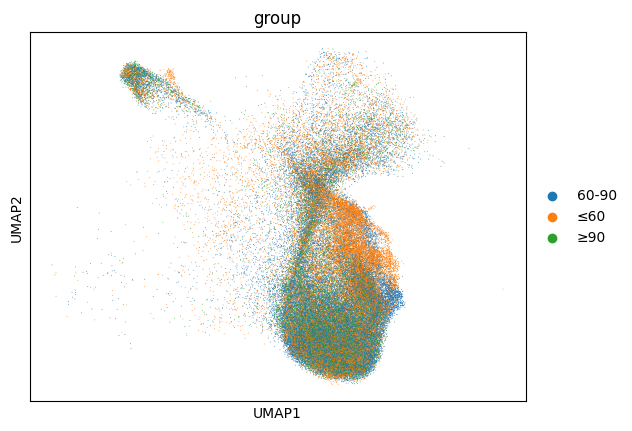

In [17]:
sc.pl.umap(adata_human,color='group')

Text(0.5, 1.0, 'UMAP with 10 Example Patches per Cluster')

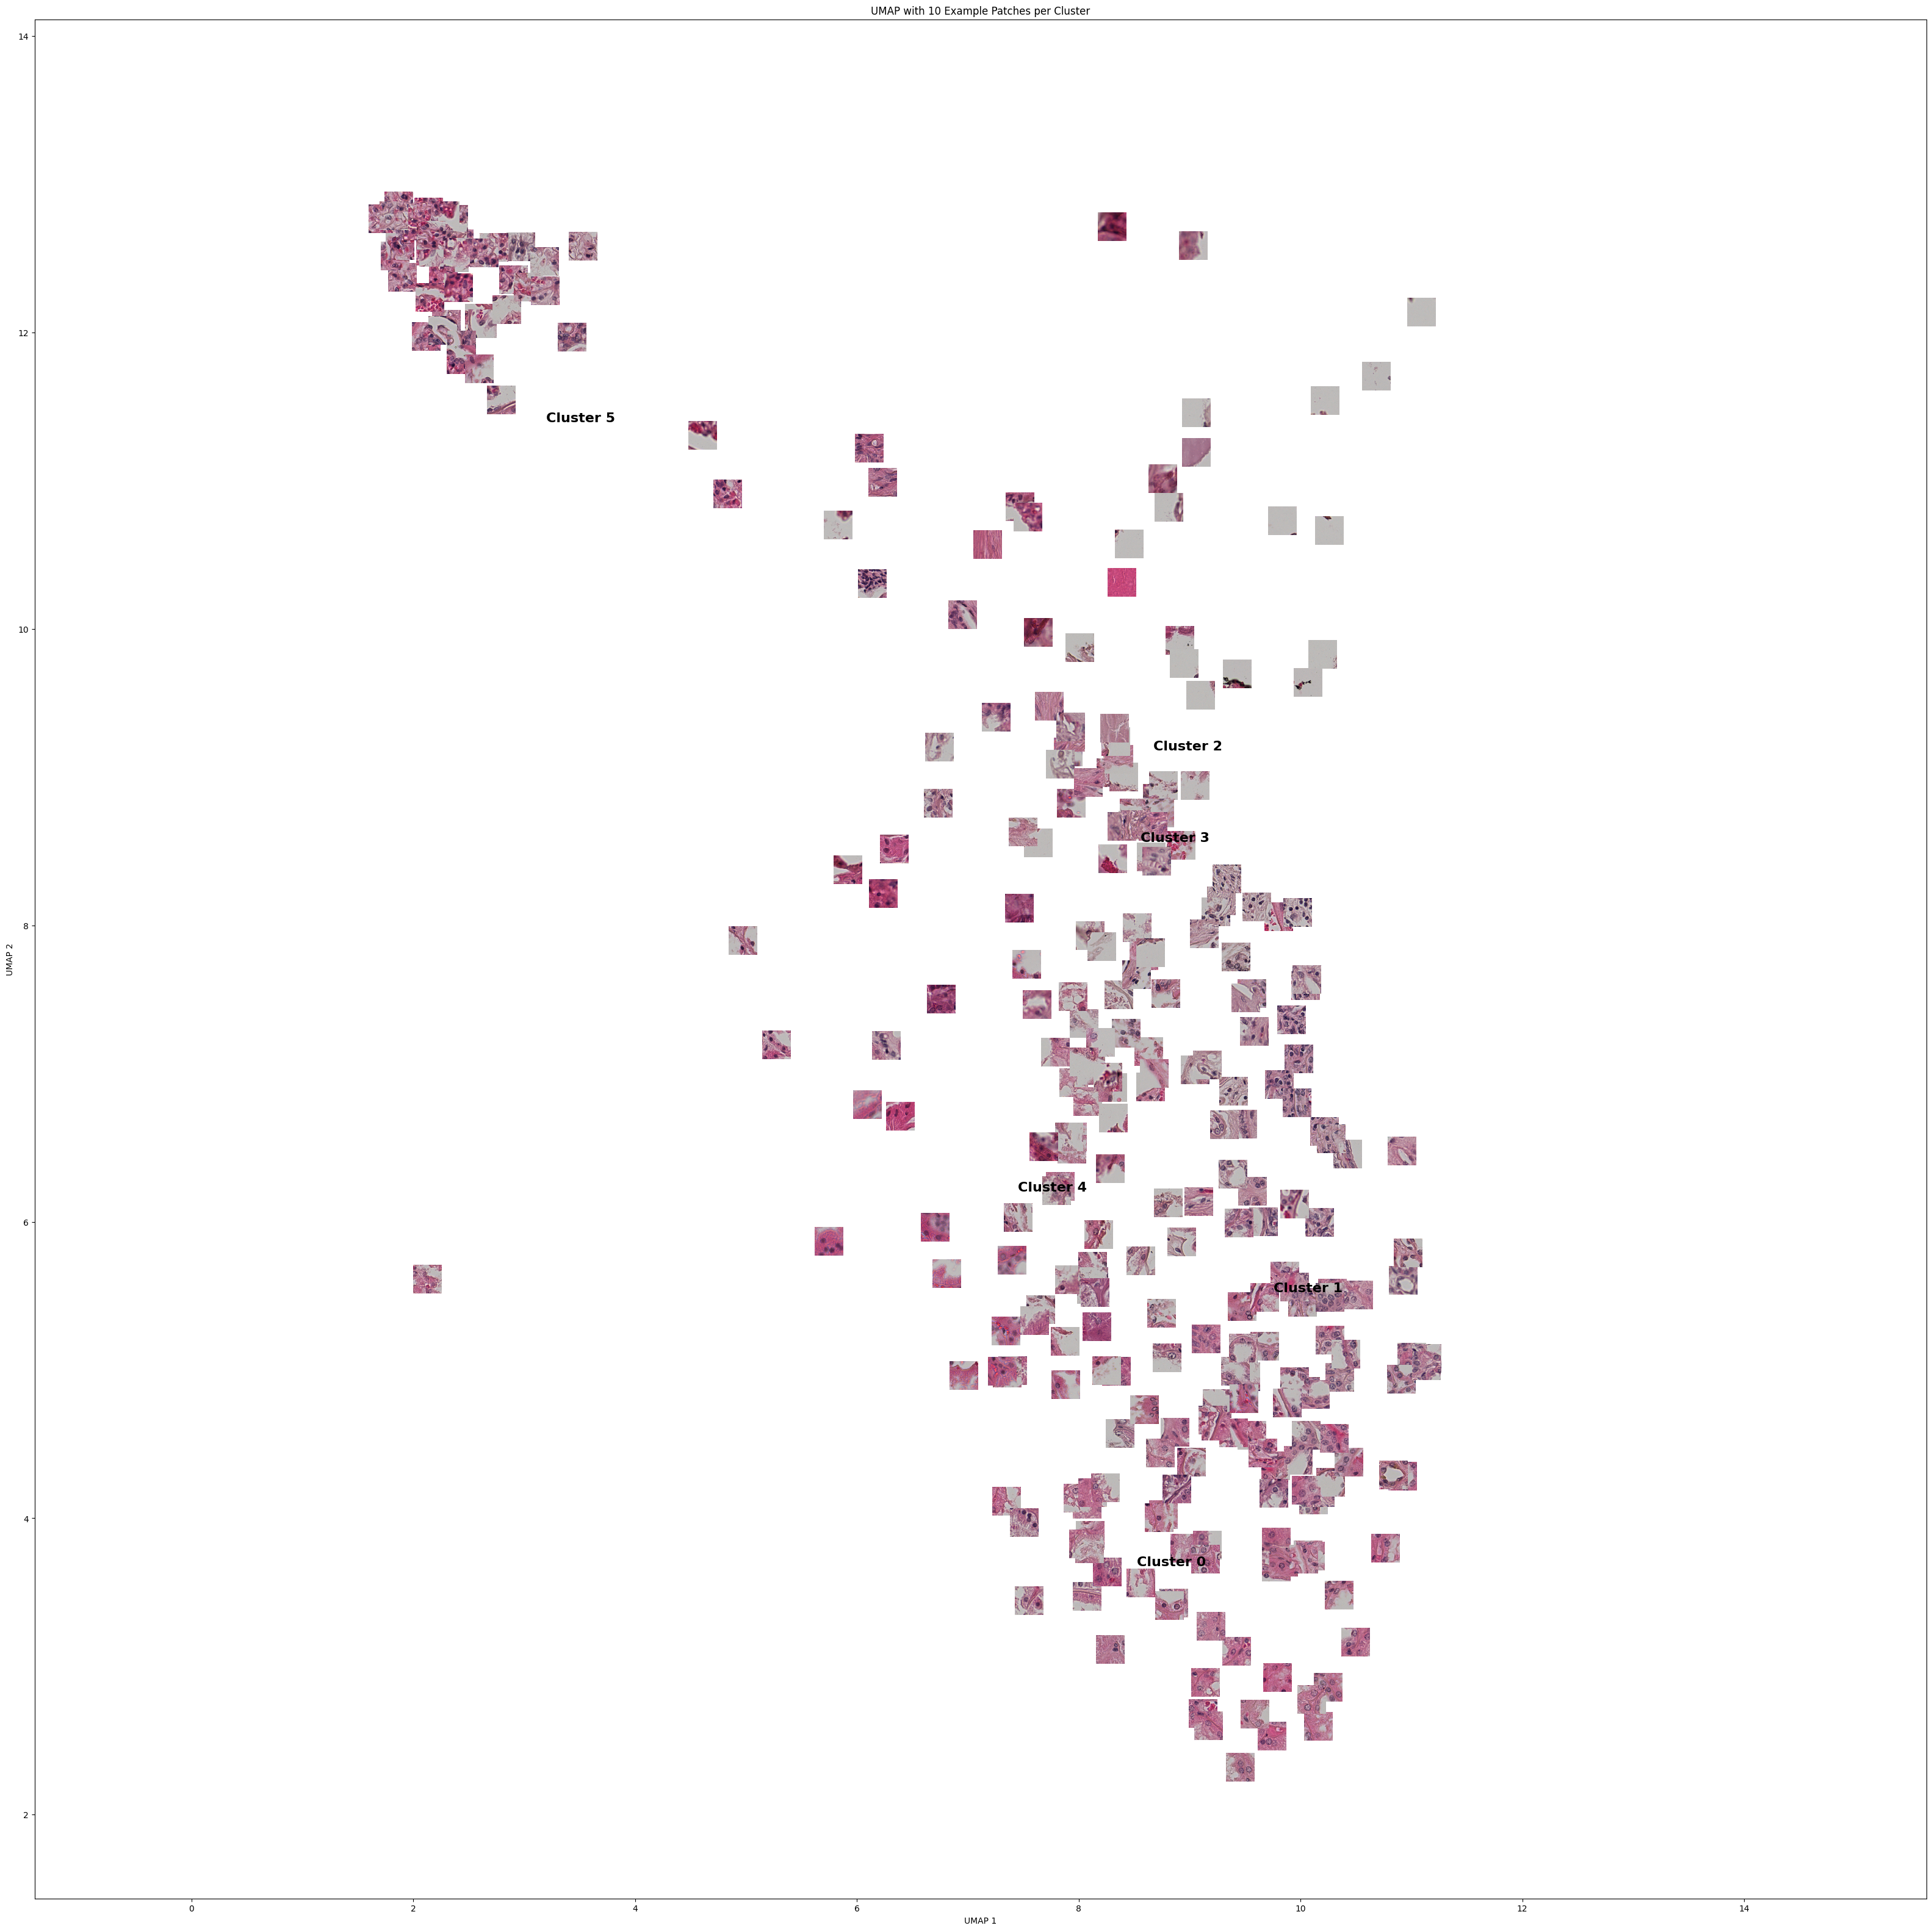

In [18]:
import os
import matplotlib.pyplot as plt
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
import numpy as np
import seaborn as sns
import random

# **Step 1: Extract UMAP Coordinates**
umap_coords = adata_human.obsm["X_umap"]
clusters = adata_human.obs["leiden"].astype(str)  # Convert Leiden clusters to strings
sample_ids = adata_human.obs["Slide_ID"].astype(str)  # Get patient/sample IDs
patch_ids = adata_human.obs["Patch_ID_x"].astype(str)  # Get patch file names

# **Step 2: Define Base Patch Folder**
patch_base_folder = "/beegfs/data/CostaLab/spatial_kidney_kuppelab/Human_mouse_all_xenium/output_patches/"

# **Step 3: Function to Load Patch Images**
def getImage(path, zoom=0.15):  # Adjust zoom level for patch size
    return OffsetImage(plt.imread(path), zoom=zoom)

# **Step 4: Create UMAP Scatter Plot**
fig, ax = plt.subplots(figsize=(40, 40))
ax.scatter(umap_coords[:, 0], umap_coords[:, 1], c="white", alpha=1, edgecolors="w", label="Cells")

# **Step 5: Process Each Cluster**
for cluster in sorted(clusters.unique()):
    # **Select 10 Random Points for this Cluster**
    cluster_indices = np.where(clusters == cluster)[0]
    if len(cluster_indices) == 0:
        continue

    selected_indices = random.sample(list(cluster_indices), min(50, len(cluster_indices)))

    # **Step 6: Overlay Patch Images**
    for i in selected_indices:
        x0, y0 = umap_coords[i]  # Get UMAP position
        sample_id = sample_ids[i]  # Get Sample ID
        patch_id = patch_ids[i]  # Get Patch file name

        # **Construct Patch Path**
        patch_folder = os.path.join(patch_base_folder, sample_id)
        patch_path = os.path.join(patch_folder, patch_id)

        if not os.path.exists(patch_path):
            print(f"Warning: Missing patch {patch_path}")
            continue

        # **Step 7: Add Patch to UMAP**
        ab = AnnotationBbox(getImage(patch_path), (x0, y0), frameon=False, box_alignment=(0.5, 0.5), pad=0)
        ax.add_artist(ab)

    # **Step 8: Annotate Cluster**
    avg_x, avg_y = np.mean(umap_coords[cluster_indices], axis=0)
    ax.annotate(f"Cluster {cluster}", (avg_x, avg_y), fontsize=16, ha="center", color="black", weight="bold")

# **Step 9: Finalize & Show Plot**
ax.set_xlabel("UMAP 1")
ax.set_ylabel("UMAP 2")
ax.set_title("UMAP with 10 Example Patches per Cluster")
#fig.savefig('Results_PILOT/Umap_patches.pdf')

In [19]:
adata_human.obs['sample_ID_']=adata_human.obs['sample_ID'].astype(str)+'_'+adata_human.obs['group'].astype(str)

Saved 40 core plots to human_patches/


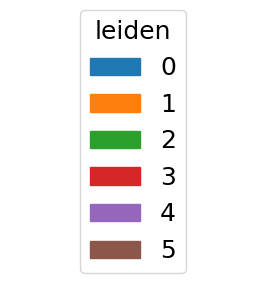

In [55]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.collections import PatchCollection
from matplotlib.patches import Rectangle

patch_size = 224  # pixels, patches are patch_size x patch_size

output_dir = "human_patches"
os.makedirs(output_dir, exist_ok=True)

# **Color mapping for leiden_04 clusters (reuse scanpy's colors if already computed)**
cluster_col = "leiden"
categories = adata_human.obs[cluster_col].cat.categories
uns_key = f"{cluster_col}_colors"
if uns_key in adata_human.uns:
    palette = adata_human.uns[uns_key]
else:
    cmap = plt.get_cmap("tab20", len(categories))
    palette = [cmap(i) for i in range(len(categories))]
color_map = dict(zip(categories, palette))

# **Plot one figure per core (Slide_ID), patches drawn at their true X,Y location/size — no legend**
for slide_id in adata_human.obs["Slide_ID"].unique():
    sub = adata_human.obs[adata_human.obs["Slide_ID"] == slide_id]
    donor_key = sub["sample_ID"].iloc[0]
    group = sub["group"].iloc[0]

    fig, ax = plt.subplots(figsize=(12, 12))

    rects = [
        Rectangle((x - patch_size / 2, y - patch_size / 2), patch_size, patch_size)
        for x, y in zip(sub["X"], sub["Y"])
    ]
    colors = [color_map[c] for c in sub[cluster_col]]
    ax.add_collection(PatchCollection(rects, facecolor=colors, edgecolor="none"))

    ax.set_xlim(sub["X"].min() - patch_size, sub["X"].max() + patch_size)
    ax.set_ylim(sub["Y"].min() - patch_size, sub["Y"].max() + patch_size)
    ax.invert_yaxis()  # image-style coordinates: Y grows downward
    ax.set_aspect("equal")
    ax.axis("off")
   # ax.set_title(f"{donor_key}_{group}  (n={len(sub)} patches)")

    fig.tight_layout()
    fig.savefig(os.path.join(output_dir, f"{donor_key}_{group}.pdf"), dpi=200, bbox_inches="tight")
    plt.close(fig)

print(f"Saved {adata_human.obs['Slide_ID'].nunique()} core plots to {output_dir}/")

# **Plot the leiden_04 color legend separately (one shared legend for all cores)**
fig, ax = plt.subplots(figsize=(3, len(categories) * 0.3))
legend_handles = [mpatches.Patch(color=color_map[c], label=c) for c in categories]
ax.legend(handles=legend_handles, title=cluster_col, loc="center")
ax.axis("off")
fig.tight_layout()
fig.savefig(os.path.join(output_dir, f"_legend_{cluster_col}.pdf"), dpi=200, bbox_inches="tight")
plt.show()

In [21]:
adata_human.obs['sample_ID_']=adata_human.obs['sample_ID'].astype(str)+'_'+adata_human.obs['group'].astype(str)

In [45]:
adata_human=adata_human[~adata_human.obs['sample_ID_'].isin(['T20-11830_≤60','T20-13558_≤60'])].copy()

In [46]:
wasserstein_distance(adata_human,emb_matrix='X_pca',
clusters_col='leiden',sample_col='sample_ID_',status='group',metric='euclidean')

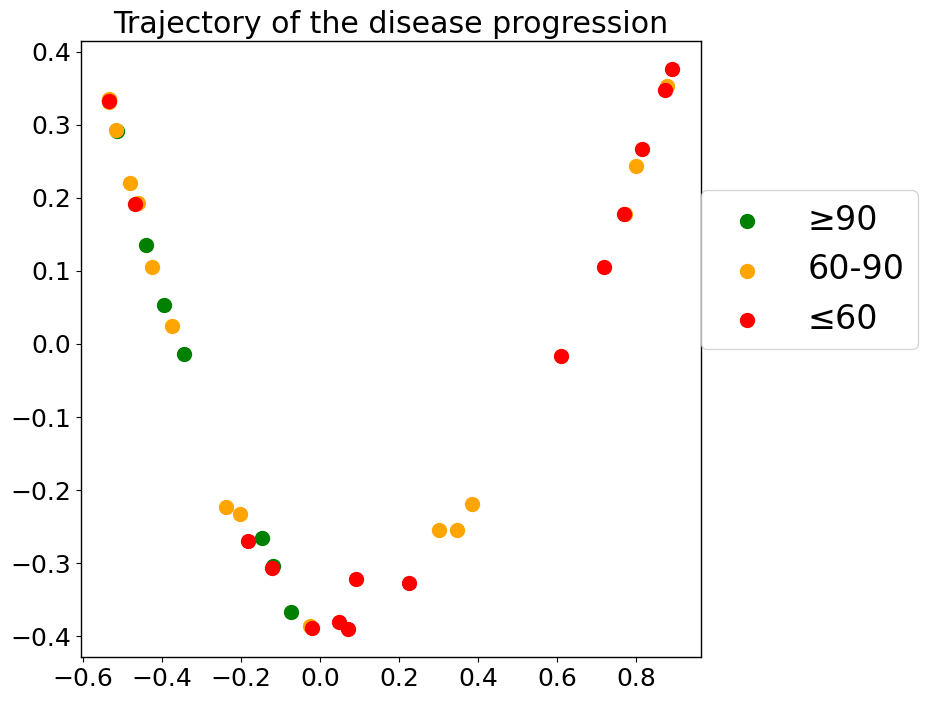

In [48]:
trajectory(adata_human,colors=['green','orange','red'],label_act=False,font_size=18,knn=15,figsize=(8,8),legend_order=['≥90','60-90','≤60'], location_labels=(1,0.5))

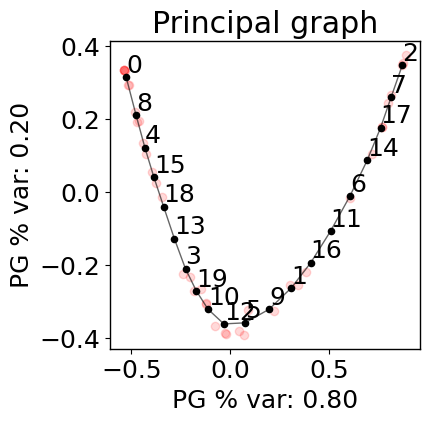

In [49]:

fit_pricipla_graph(adata_human, source_node =0,figsize=(4,4))

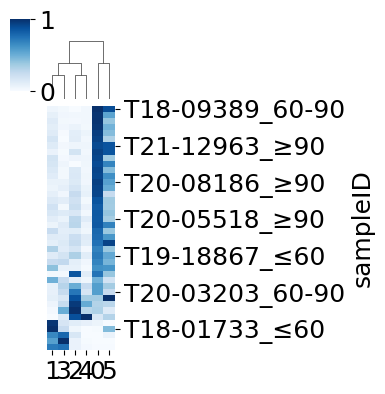

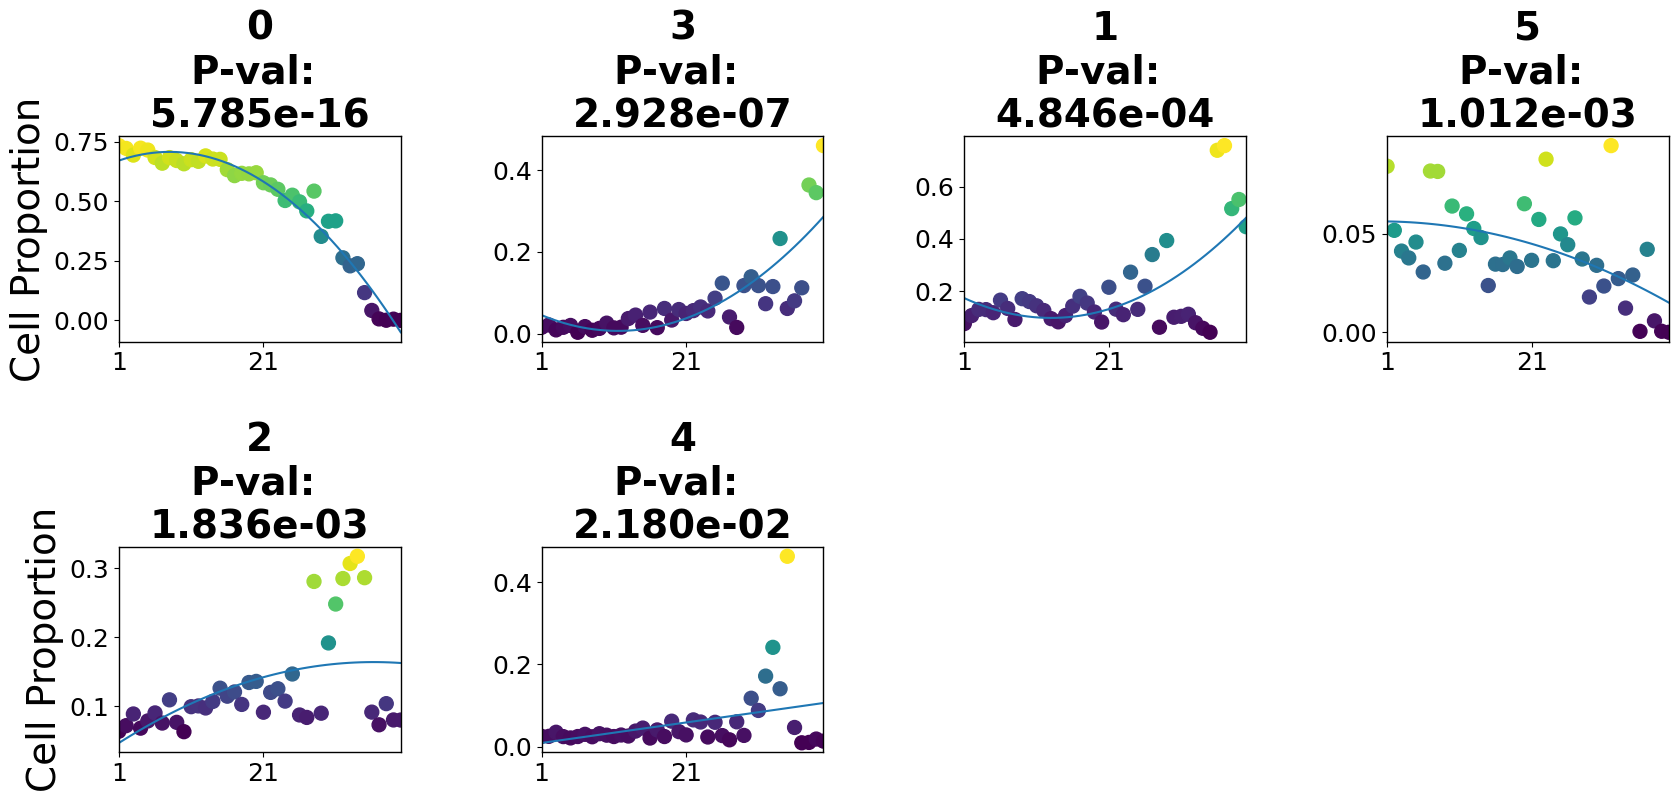

In [50]:
cell_importance(adata_human,height=8,width=20,fontsize=28,xlim=20,figsize=(4,4))

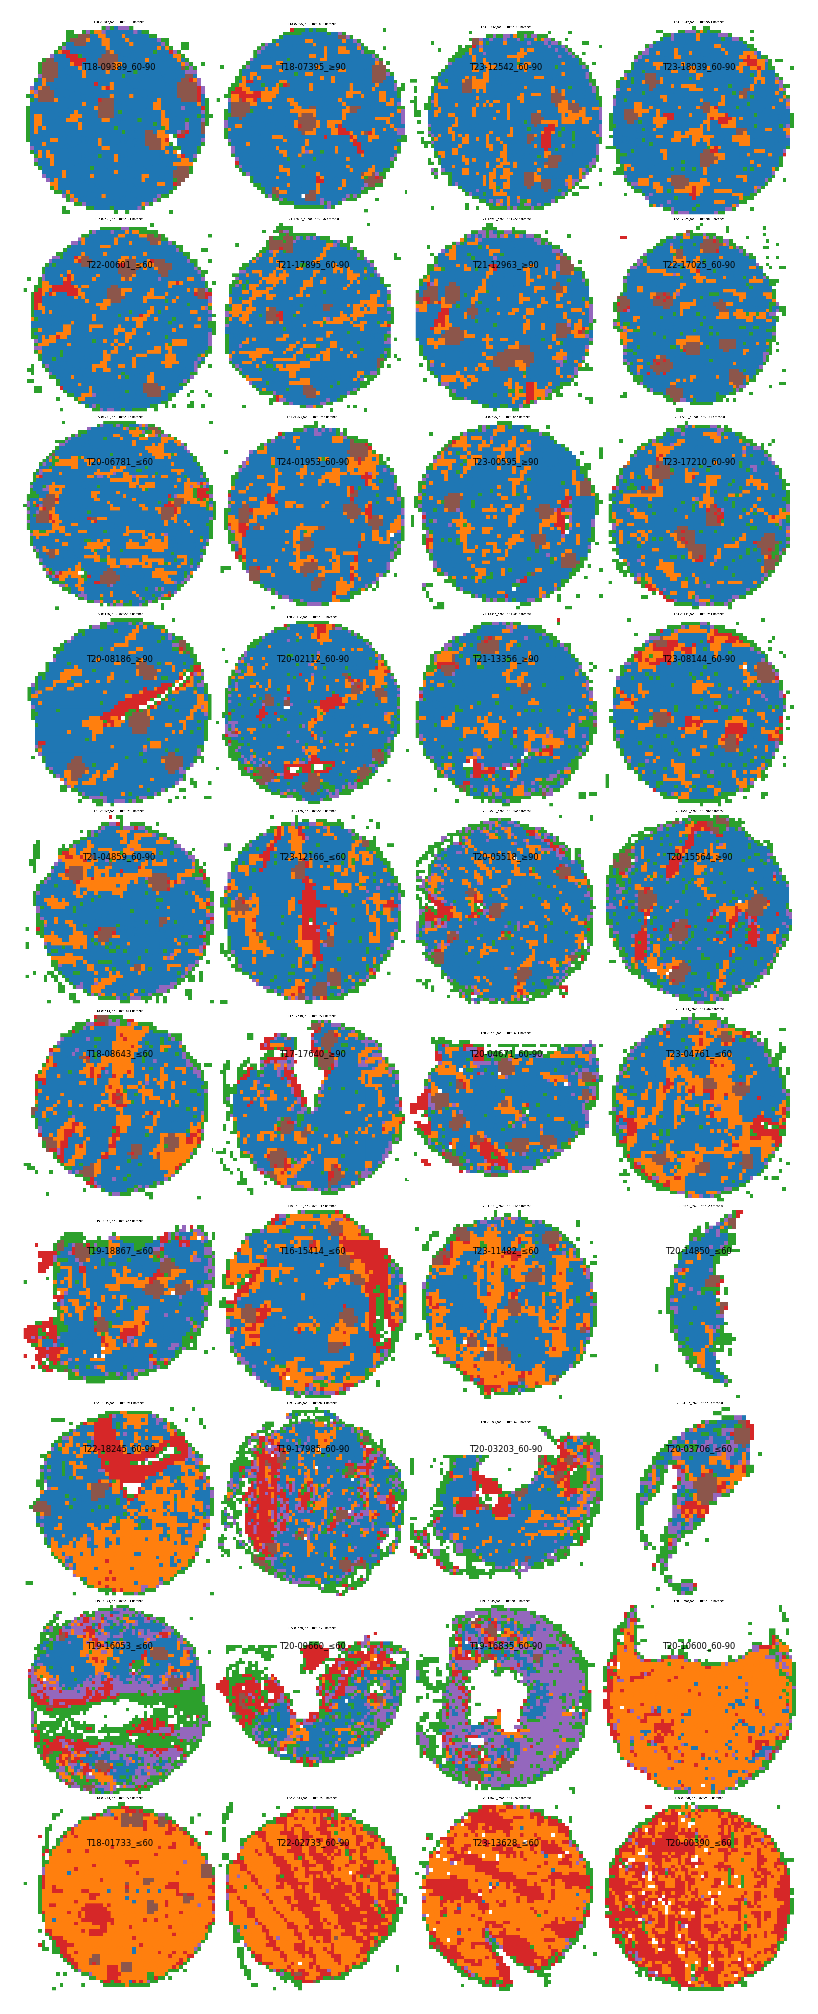

Saved grid to Results_PILOT/Cores_Patche_ordered.pdf


In [51]:
adata_human.uns['orders'].rename(columns={'Time_score': 'pseudotime'}, inplace=True)
create_sample_grid(df=adata_human.uns['orders'],image_dir='human_patches/', output_path="Results_PILOT/Cores_Patche_ordered.pdf",zoom=0.06)

In [ ]:
import os
from PIL import Image

# **Reassemble each core from its real saved patches (puzzle), placed at their true X,Y**
patch_size = 224
patch_base_folder = "/beegfs/data/CostaLab/spatial_kidney_kuppelab/Human_mouse_all_xenium/output_patches/"
output_dir_real = "/beegfs/data/CostaLab/spatial_kidney_kuppelab/Human_mouse_all_xenium/human_cores"
os.makedirs(output_dir_real, exist_ok=True)

for slide_id in adata_human.obs["Slide_ID"].unique():
    sub = adata_human.obs[adata_human.obs["Slide_ID"] == slide_id]

    # top-left corner of each patch (X,Y are patch centers)
    left = sub["X"] - patch_size / 2
    top = sub["Y"] - patch_size / 2

    canvas_x0, canvas_y0 = left.min(), top.min()
    canvas_w = int(left.max() + patch_size - canvas_x0)
    canvas_h = int(top.max() + patch_size - canvas_y0)

    canvas = Image.new("RGB", (canvas_w, canvas_h), color=(255, 255, 255))

    patch_folder = os.path.join(patch_base_folder, str(slide_id))
    n_missing = 0

    for _, row in sub.iterrows():
        patch_path = os.path.join(patch_folder, str(row["Patch_ID_x"]))
        if not os.path.exists(patch_path):
            n_missing += 1
            continue

        patch_img = Image.open(patch_path).convert("RGB")
        if patch_img.size != (patch_size, patch_size):
            patch_img = patch_img.resize((patch_size, patch_size))

        px = int(row["X"] - patch_size / 2 - canvas_x0)
        py = int(row["Y"] - patch_size / 2 - canvas_y0)
        canvas.paste(patch_img, (px, py))

    canvas.save(os.path.join(output_dir_real, f"{slide_id}.png"))
    print(f"{slide_id}: saved {canvas.size} mosaic, {len(sub)} patches, {n_missing} missing")

In [27]:
def trajectory(adata, n_evecs=2, epsilon=1, alpha=0.5, knn=64, sample_col=1, 
               clusters='status', label_act=False, colors=['#377eb8', '#ff7f00', '#e41a1c'],
               legend_order=None, legend_outside=False, location_labels='center', 
               figsize=(12,12), font_size=24, axes_line_width=1, axes_color='black',
               facecolor='white', point_size=100, cmap='viridis', fontsize_legend=24,
               alpha_trans=1, plot_title="Trajectory of the disease progression"):
    
    """
    Find trajectories using Diffusion Maps and visualize the trajectory plot.

    Parameters
    ----------
    adata : AnnData
        Annotated data matrix containing EMD, annotations, and other necessary data.
    n_evecs : int, optional
        Number of embedding vectors, by default 2.
    epsilon : float or str, optional
        Method for choosing the epsilon in diffusion maps, by default 1.
    alpha : float, optional
        Normalization parameter in the bandwidth function, by default 0.5.
    knn : int, optional
        Number of nearest neighbors for constructing the kernel, by default 64.
    sample_col : int, optional
        Index of the column representing sample IDs in annotation data, by default 1.
    clusters : str, optional
        Name of the column representing clusters/categories in annotation data, by default 'status'.
    label_act : bool, optional
        Whether to label data points with sample IDs, by default False.
    colors : list, optional
        List of colors for different categories, by default ['#377eb8', '#ff7f00', '#e41a1c'].
    legend_order : list, optional
        List specifying the order of categories in legend, by default None.
    legend_outside : bool, optional
        Whether to place legend outside the plot, by default False.
    location_labels : str, optional
        Location of the legend labels when inside plot, by default 'center'.
    figsize : tuple, optional
        figsize, by default (12,12).
    font_size : int, optional
        Font size for labels and annotations, by default 24.
    axes_line_width : float, optional
        Line width of the axes, by default 1.
    axes_color : str, optional
        Color of the axes lines, by default 'black'.
    facecolor : str, optional
        Background color of the figure, by default 'white'.
    point_size : int, optional
        Size of the data points in the plot, by default 100.
    cmap : str, optional
        Colormap for scatter plot, by default 'viridis'.
    fontsize_legend : int, optional
        Font size of the legend, by default 24.
    alpha_trans : float, optional
        Transparency level for data points, by default 1.
    plot_title : str, optional
        Title of the plot, by default "Trajectory of the disease progression".

    Returns
    -------
    None
        Visualizes and saves the trajectory plot.
    """
    
    import os
    import matplotlib.pyplot as plt
    from matplotlib import cycler
    import numpy as np
    import pandas as pd
    
    EMD = adata.uns['EMD'] / adata.uns['EMD'].max()
    df = adata.uns['annot']
    
    path = 'Results_PILOT/plots'
    
    if not os.path.exists(path):
        os.makedirs(path)
    
    # استفاده از colors برای custom_cycler
    custom_cycler = (cycler(color=colors))
    
    mydmap = diffusion_map.DiffusionMap.from_sklearn(n_evecs=n_evecs, epsilon=epsilon, 
                                                      alpha=alpha, k=knn)
    embedding = mydmap.fit_transform(EMD)
    
    plt.rcParams.update({'font.size': font_size})
    plt.rcParams["axes.edgecolor"] = axes_color
    plt.rcParams["axes.linewidth"] = axes_line_width
    
    df = df.drop_duplicates(subset=[df.columns[sample_col]])
    
    # تعیین اندازه figure با توجه به موقعیت legend
    if legend_outside:
        fig = plt.figure(figsize=(figsize[0] + 2, figsize[1]))
    else:
        fig = plt.figure(figsize=figsize)
    
    ax = plt.gca()
    ax.set(facecolor=facecolor)
    ax.set_prop_cycle(custom_cycler)
    
    # تعیین ترتیب categories
    categories = df[clusters].unique()
    if legend_order is not None:
        # فقط categories موجود در legend_order را نگه می‌داریم
        categories = [cat for cat in legend_order if cat in categories]
        # اضافه کردن categories که در legend_order نیستند به انتها
        remaining_cats = [cat for cat in df[clusters].unique() if cat not in legend_order]
        categories.extend(remaining_cats)
    
    # رسم داده‌ها با ترتیب مشخص شده
    handles = []
    labels = []
    
    for category in categories:
        aux = np.array(df[clusters] == category)
        group_data = embedding[aux]
        
        # اطمینان از اینکه حداقل یک نقطه برای این category وجود دارد
        if len(group_data) > 0:
            scatter = ax.scatter(group_data[:, 0], group_data[:, 1], 
                                alpha=alpha_trans, label=category, 
                                cmap=cmap, s=point_size)
            handles.append(scatter)
            labels.append(category)
            
            if label_act:
                names = np.array(df[df[clusters] == category].sampleID)
                for k, txt in enumerate(names):
                    ax.annotate(txt, (group_data[k, 0], group_data[k, 1]), 
                              fontsize=font_size)
    
    # تنظیم موقعیت legend
    if legend_outside:
        # قرار دادن legend در بیرون plot
        ax.legend(handles, labels, loc='center left', 
                 fontsize=fontsize_legend, bbox_to_anchor=(1, 0.5))
        # تنظیم margins برای جا دادن legend
        plt.subplots_adjust(right=0.85)
    else:
        ax.legend(handles, labels, loc=location_labels, fontsize=fontsize_legend)
    
    plt.title(plot_title)
    plt.savefig(path + "/" + plot_title + '.pdf', bbox_inches='tight')
    plt.show()
    plt.close(fig)
    
    adata.uns['embedding'] = embedding


def plot_umap_and_stacked_bar(
    adata, 
    cell_type_col, 
    component_col='component_assignment', 
    palette_name=None, 
    title="Cell Type vs Component Assignment", 
    xlabel="Component Assignment", 
    ylabel="Proportion", 
    save_path='figures/Bar_plot.png', 
    umap_save_name="_components_vs_cell_types.png", 
    umap_size=5, 
    umap_legend_fontsize=10, 
    umap_ncols=2, 
    umap_wspace=0.55, 
    bar_figsize=(14, 8), 
    umap_figsize=(10, 10), 
    axes_titlesize=18, 
    axes_labelsize=16, 
    legend_fontsize=14, 
    legend_bbox_to_anchor=(1.05, 1), 
    legend_loc='upper left', 
    legend_borderaxespad=0.0
):
    """
    Plots a UMAP and a normalized stacked bar chart of component assignments vs. cell types.

    Parameters:
        adata: Input AnnData object.
        cell_type_col (str): Name of the column containing cell type annotations.
        component_col (str): Name of the column containing component assignments.
        palette_name (str, optional): Name of the palette or a custom palette list to use for coloring.
        title (str, optional): Title of the plot.
        xlabel (str, optional): Label for the x-axis.
        ylabel (str, optional): Label for the y-axis.
        save_path (str, optional): File path to save the bar plot (PDF or PNG). If None, the plot is not saved.
        umap_save_name (str, optional): File name for saving the UMAP plot.
        umap_size (int, optional): Point size for the UMAP plot.
        umap_legend_fontsize (int, optional): Font size for the UMAP legend.
        umap_ncols (int, optional): Number of columns for the UMAP plots.
        umap_wspace (float, optional): Width space between UMAP plots.
        bar_figsize (tuple, optional): Figure size for the bar plot.
        umap_figsize (tuple, optional): Figure size for the UMAP plot.
        axes_titlesize (int, optional): Font size for axes titles.
        axes_labelsize (int, optional): Font size for axes labels.
        legend_fontsize (int, optional): Font size for the legend.
        legend_bbox_to_anchor (tuple, optional): Anchor position for the legend.
        legend_loc (str, optional): Location of the legend.
        legend_borderaxespad (float, optional): Padding between legend and axes border.

    Returns:
        None
    """
    # Ensure component_col is treated as a string
    #adata.obs[component_col] = adata.obs[component_col].astype(str)

    # Set default palette if none is provided
    adata.obs['component_assignment'] = adata.obs['component_assignment'].astype(str)
    if palette_name is None:
        palette = sns.color_palette("Set1", 9) + sns.color_palette("Set2", 8) + sns.color_palette("Set3", 12) + sns.color_palette("Dark2", 4)
        palette = palette[:33]  # Limit the palette to exactly 33 colors
    else:
        palette = palette_name

    # Plot UMAP
    sc.pl.umap(
        adata,
        color=[component_col, cell_type_col],
        save=umap_save_name,  
        ncols=umap_ncols, 
        wspace=umap_wspace, 
        legend_fontsize=umap_legend_fontsize, 
        size=umap_size, 
        palette=palette
    )

    # Set font properties globally
    plt.rc('axes', titlesize=axes_titlesize)  # Set font size for axes titles
    plt.rc('axes', labelsize=axes_labelsize)  # Set font size for axes labels
    plt.rc('legend', fontsize=legend_fontsize)  # Set font size for legend

    # Prepare data for the stacked bar plot
    df = pd.DataFrame({
        'component_assignment': adata.obs[component_col],
        'Cell Type': adata.obs[cell_type_col]
    })

    # Create a cross-tab to get counts (no normalization)
    cross_tab = pd.crosstab(df[component_col], df['Cell Type'])

    # Normalize each row to ensure bars have the same total length
    cross_tab_normalized = cross_tab.div(cross_tab.sum(axis=1), axis=0)

    # Plot as a stacked bar plot using the custom palette (with normalization)
    plt.figure(figsize=bar_figsize)  # Use dynamic figure size for bar plot
    ax = cross_tab_normalized.plot(kind='bar', stacked=True, color=palette[:33], figsize=bar_figsize)

    # Add labels and titles
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(title)

    # Move legend to the right side of the plot
    plt.legend(
        title='Cell Type', 
        bbox_to_anchor=legend_bbox_to_anchor, 
        loc=legend_loc, 
        borderaxespad=legend_borderaxespad
    )

    # Save the plot as a file if save_path is provided
    if save_path:
        plt.savefig(save_path, bbox_inches='tight')

    # Show the plot
    plt.tight_layout()
    plt.show()


In [24]:

import scanpy as sc
#from pilot_gm_vae import *



from matplotlib.offsetbox import OffsetImage, AnnotationBbox
def create_sample_grid(df, image_dir='/data/scRNA/To_Mehdi/pan_data/xei/Human/colored_patches_cluters_/', output_path="Results_PILOT/Histology_figures/sample_grid_cores.png",zoom=0.15,num_rows = 10):
    """
    Create a grid of sample images based on ordering in a DataFrame.
    
    Args:
        df: DataFrame containing at least:
            - 'sampleID': unique sample identifiers
            - 'order': numerical ordering for sorting
        image_dir: Directory containing images (named as {sampleID}.png)
        output_path: Where to save the resulting grid
    """
    # Sort samples by the specified order
    sorted_df = df.sort_values('pseudotime')
    sample_names = sorted_df['sampleID'].tolist()
    
    # Calculate grid dimensions (10 rows, auto columns)
    num_samples = len(sample_names)
    num_rows = num_rows
    num_cols = math.ceil(num_samples / num_rows)
    
    # Prepare figure
    fig, axes = plt.subplots(num_rows, num_cols, 
                           figsize=(num_cols * 2, num_rows * 2))
    axes = axes.flatten()
    
    # Image loading function
    def get_image(path, zoom=zoom):
        if os.path.exists(path):
            return OffsetImage(plt.imread(path), zoom=zoom)
        return None
    
    # Plot each sample
    for i, sample in enumerate(sample_names):
        img_path = os.path.join(image_dir, f"{sample}.png")
        ax = axes[i]
        
        # Add image if exists
        img = get_image(img_path)
        if img:
            ab = AnnotationBbox(img, (0.5, 0.5), 
                              frameon=False, 
                              box_alignment=(0.5, 0.5))
            ax.add_artist(ab)
        
        # Minimal labeling
        ax.set_title(sample, fontsize=6)
        ax.set_xticks([])
        ax.set_yticks([])
        ax.axis('off')
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.spines['bottom'].set_visible(False)
        ax.spines['left'].set_visible(False)
    
    # Hide unused subplots
    for i in range(num_samples, len(axes)):
        axes[i].axis('off')
    
    
    
    plt.tight_layout()
    fig.canvas.draw()  # Force render
    plt.savefig(output_path, dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()
    print(f"Saved grid to {output_path}")
